<div style="text-align: center;">

# Asset Impact API Basics: Request and Visualize Hazard and Impact Distributions

</div>

This notebook is the next step after the hazard-data basics notebook. Instead of requesting raw hazard curves at points, it asks the Alpha-Klima API to combine hazard data with an asset definition and the relevant vulnerability logic, producing an impact distribution for that asset.

The workflow is:

1. Load API credentials from the local environment.
2. Query the availability endpoint to confirm which hazards and indicators are supported.
3. Define one example asset and explain why its metadata matters.
4. Select the hazard indicators to include in the analysis.
5. Build an `/api/get_asset_impact_clean` request.
6. Submit the request and inspect the response structure.
7. Flatten the nested impact records into a table.
8. Visualize both the hazard distribution and the resulting impact distribution.

The example focuses on one `RealEstateAsset` exposed to `RiverineInundation` through the `flood_depth` indicator, but the same response structure generalizes to multiple assets, hazards, scenarios, and years.

## 1. Imports

When you run the notebook for the first time, select `.venv` as the interpreter. If you are unable to find the `.venv` interpreter, please follow the *Setup* instructions in the `README.md` to set it up.

The notebook uses:

- `requests` for HTTPS calls to the Alpha-Klima API.
- `pandas` for table-oriented inspection of the nested JSON response.
- `plotly` for interactive bar charts of probability distributions.
- `python-dotenv` so credentials can live in `.env` instead of inside the notebook.

In [1]:
import os

import pandas as pd
import plotly.graph_objects as go
import requests
from dotenv import load_dotenv

In [2]:
# Render Plotly figures in both live notebooks and static notebook previews.
import plotly.io as pio

pio.renderers.default = "notebook+png"

## 2. Load API Configuration

The API base URL and API key are read from `../../.env`. If you have not configured the `.env` file, please follow the *API credentials* instructions in the `README.md` to set it up.

Expected environment variables:

- `ALPHA_KLIMA_API_KEY`: API key used to authenticate API calls.
- `ALPHA_KLIMA_API_BASE_URL`: base URL of the Alpha-Klima API.

Keeping this setup in one cell makes it easier to reuse the same credentials for several endpoint calls.

In [3]:
_ = load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")

if not API_KEY or not API_BASE:
    raise RuntimeError(
        "Set ALPHA_KLIMA_API_KEY and ALPHA_KLIMA_API_BASE_URL in ../../.env before running this notebook."
    )

HEADERS = {"X-API-Key": API_KEY, "Accept": "application/json"}

## 3. Define a Small API Helper

The API returns JSON for successful calls and an HTTP error for failed calls. This helper keeps request handling consistent across the notebook:

- it joins the base URL and endpoint path,
- sends the same authentication headers every time,
- raises an exception when the API returns an error status,
- and returns parsed JSON for successful responses.


In [4]:
def api_post(endpoint: str, payload: dict, timeout: int = 240) -> dict:
    """POST a JSON payload to the Alpha-Klima API and return the parsed JSON response."""
    response = requests.post(
        f"{API_BASE}{endpoint}",
        json=payload,
        headers=HEADERS,
        timeout=timeout,
    )
    response.raise_for_status()
    return response.json()

## 4. Discover Available Hazard Sources

Before building an impact request, query `/api/get_available_sources` to see which hazard families, indicators, scenarios, and years are available for the current API key and use case.

This notebook uses `use_case_id="ECB_SCORES"`, used in the current examples in this repository. If your API access is configured for a different use case, update the request accordingly.

In [5]:
availability_request = {
    "include_all": False,
    "use_case_id": "ECB_SCORES",
    "selected_hazards_list": [],
}

dict_available_sources = api_post("/api/get_available_sources", availability_request)

In [6]:
def available_sources_to_table(available_sources: dict) -> pd.DataFrame:
    """Flatten the availability response into one row per hazard indicator."""
    rows = []

    for hazard_type, indicators in available_sources.get("hazards", {}).items():
        for indicator_id, metadata in indicators.items():
            rows.append(
                {
                    "hazard_type": hazard_type,
                    "indicator_id": indicator_id,
                    "indicator_display_name": metadata.get("indicator_display_name", ""),
                    "scenario_years": [
                        {"scenario": scenario["id"], "years": scenario.get("years", [])}
                        for scenario in metadata.get("scenarios", [])
                    ],
                    "available_for_asset_types": metadata.get("available_for_assets_type", []),
                }
            )

    return pd.DataFrame(rows).sort_values(["hazard_type", "indicator_id"]).reset_index(drop=True)


available_sources_df = available_sources_to_table(dict_available_sources)
available_sources_df.head(20)

,hazard_type,indicator_id,indicator_display_name,scenario_years,available_for_asset_types
0,ChronicHeat,cooling_degree_days/index,Cooling Degree Days (Alpha-Klima),"[{'scenario': 'historical', 'years': [2005]}, ...","[RealEstateAsset, TelecommunicationAsset]"
1,ChronicHeat,days_wbgt_above,Days With Wet-Bulb Globe Temperature Above Thr...,"[{'scenario': 'historical', 'years': [2005]}, ...",[ManufacturingAsset]
2,ChronicHeat,mean_degree_days/above/32c,Mean Degree Days Above 32°C (ACCESS-CM2),"[{'scenario': 'historical', 'years': [2005]}, ...",[IndustrialActivity]
3,ChronicHeat,mean_work_loss/high,"Mean Work Loss, high Intensity (ACCESS-CM2)","[{'scenario': 'historical', 'years': [2005]}, ...",[IndustrialActivity]
4,CoastalInundation,flood_depth,Coastal Flood Depth (RAIN Project),"[{'scenario': 'historical', 'years': [1971]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
5,Drought,cdd,Consecutive Dry Days (Copernicus),"[{'scenario': 'historical', 'years': [1995]}, ...","[RealEstateAsset, TelecommunicationAsset, Infr..."
6,Drought,spi6,"Standardized Precipitation Index, SPI-6 (Coper...","[{'scenario': 'historical', 'years': [1995]}, ...","[RealEstateAsset, TelecommunicationAsset, Infr..."
7,Earthquake,pga_10pc50yr,"Peak Ground Acceleration, 10% Exceedance in 50...","[{'scenario': 'historical', 'years': [2023]}]","[RealEstateAsset, TelecommunicationAsset, Infr..."
8,Fire,fire_probability,Annual Wildfire Probability (Alpha-Klima),"[{'scenario': 'historical', 'years': [2010]}, ...","[UtilityAsset, OilGasAsset, RealEstateAsset, T..."
9,FreezingRain,freezing_rain_probability,Annual Freezing Rain Probability (RAIN Project),"[{'scenario': 'historical', 'years': [1985]}, ...","[RealEstateAsset, TelecommunicationAsset, Infr..."


## 5. Define the Asset to Assess

The asset-impact endpoint expects an `assets.items` list. Each item is an asset with the metadata needed to:

- locate the asset geographically,
- identify its asset class,
- and choose the relevant vulnerability logic for that type of asset.

In this example, we define one industrial real-estate asset in Spain. In a client workflow, this list usually comes from an internal asset register or exposure table and may contain many assets in a single request.

### Example Asset Payload

The most important fields to notice are `asset_class` and `type`. Those fields help determine which impact models can be applied to the hazard intensity returned for the asset location.

In [7]:
asset = {
    "items": [
        {
            "id": "0",
            "asset_name": "Europe_1",
            "asset_class": "RealEstateAsset",
            "type": "Buildings/Industrial",
            "location": "Europe",
            "country": "ES",
            "latitude": 41.3070,
            "longitude": 2.0567,
        },
    ]
}

asset_financial = {
    "asset value": 25_000_000,
}

## 6. Select Hazard Indicators

`hazard_dictionary` defines the hazard scope passed to the impact engine.

Keys are hazard families and values are the indicator IDs to request for each family. This notebook keeps the active example simple and only asks for riverine flood depth.

The commented examples show other combinations you may explore after checking the availability table.

In [8]:
hazard_dictionary = {
    "RiverineInundation": ["flood_depth"],
    # "Wind": ["wind_speed/3s"],
    # "CoastalInundation": ["flood_depth"],
    # "Drought": ["spi6", "cdd"],
    # "Landslide": ["landslide_susceptability"],
    # "Subsidence": ["subsidence_susceptability"],
    # "WaterRisk": ["water_stress"],
    # "Fire": ["fire_probability"],
    # "GroundShaking": ["pga_10pc50yr"],
    # "ChronicHeat": ["mean_degree_days/above/index", "mean_degree_days/above/32c", "mean_work_loss/high"],
}

## 7. Build the Asset Impact Request

The request sent to `/api/get_asset_impact_clean` combines:

- the asset definition,
- requested scenarios and years,
- a use-case configuration,
- and calculation settings that define the hazard scope and interpolation behavior.

This example requests `rcp4p5` for 2035 and 2085 without interpolation.

In [9]:
request_dict = {
    "assets": asset,
    "include_asset_level": True,
    "include_measures": True,
    "include_calc_details": True,
    "clean_response": True,
    "use_case_id": "ECB_SCORES",
    "years": [2035, 2085],
    "scenarios": ["rcp4p5"],
    "calc_settings": {
        "hazard_scope_by_indicator": hazard_dictionary,
        "interpolate_years": False,
    },
}

## 8. Execute the Asset Impact Request

The JSON response is stored as `dict_asset_impact`. When `include_asset_level=True`, the response contains one entry per requested asset under `asset_impacts`.

Each asset entry contains an `impacts` list. Each impact record corresponds to one hazard, indicator, scenario, and year combination, and can include:

- `impact_distribution`: the probability distribution of the calculated impact,
- `impact_exceedance`: the exceedance view of that same impact,
- `impact_mean`: a summary statistic,
- `calc_details.hazard_distribution`: the underlying hazard distribution used by the impact model.

In [10]:
dict_asset_impact = api_post("/api/get_asset_impact_clean", request_dict)

### Inspect One Asset Result

Looking at a single asset entry is the fastest way to understand the nesting before flattening it into a table.

In [11]:
dict_asset_impact["asset_impacts"][0]

{'asset_id': '0',
 'impacts': [{'key': {'hazard_type': 'RiverineInundation',
    'scenario_id': 'historical',
    'year': '1985'},
   'impact_type': 'damage',
   'hazard_indicator_id': 'flood_depth',
   'impact_distribution': {'bin_edges': [0.391, 0.401, 0.411, 0.411],
    'probabilities': [0.006667, 0.002333, 0.001]},
   'impact_exceedance': {'values': [0.391, 0.401, 0.411, 0.411],
    'exceed_probabilities': [0.01, 0.003333, 0.001, 0.0]},
   'impact_mean': 0.003998,
   'impact_std_deviation': 0.03979,
   'impact_semi_std_deviation': 0.03959,
   'calc_details': {'hazard_exceedance': {'values': [2.91, 3.06, 3.216, 3.216],
     'exceed_probabilities': [0.01, 0.003333, 0.001, 0.0]},
    'hazard_distribution': {'bin_edges': [2.91, 3.06, 3.216, 3.216],
     'probabilities': [0.006667, 0.002333, 0.001]},
    'vulnerability_distribution': {'intensity_bin_edges': [2.91,
      3.06,
      3.216,
      3.216],
     'impact_bin_edges': [0.391, 0.401, 0.411, 0.411],
     'prob_matrix': [[1.0, 0.0

## 9. Extract Impact Records

This example only requests one asset, so the records we want are located at `dict_asset_impact["asset_impacts"][0]["impacts"]`.

In a multi-asset workflow, you would normally loop over `asset_impacts` and keep the `asset_id` alongside the individual impact records.

In [12]:
asset_impacts = dict_asset_impact["asset_impacts"][0]["impacts"]

## 10. Define Distribution Helpers

The hazard and impact distributions returned by the API are binned probability distributions. They use:

- `bin_edges`: the boundaries between bins,
- `probabilities`: the probability mass allocated to each bin.

Plotly bar charts need one x-position and one width per bin, so the helper below converts edges into midpoints and widths.

In [13]:
def compute_bar_params(distribution: dict) -> tuple[list[float], list[float], list[float]]:
    """Convert a binned distribution into Plotly bar positions, widths, and heights."""
    edges = distribution["bin_edges"]
    probabilities = distribution["probabilities"]

    midpoints = []
    widths = []
    for i in range(len(edges) - 1):
        low = edges[i]
        high = edges[i + 1]
        midpoints.append((low + high) / 2)
        widths.append(high - low)

    return midpoints, widths, probabilities


def distribution_to_figure(
    distribution: dict,
    *,
    title: str,
    xaxis_title: str,
    yaxis_title: str = "Probability mass",
    color: str = "#0f766e",
) -> go.Figure:
    """Render one API distribution as a bar chart."""
    midpoints, widths, probabilities = compute_bar_params(distribution)

    fig = go.Figure(
        go.Bar(
            x=midpoints,
            y=probabilities,
            width=widths,
            marker_color=color,
            opacity=0.75,
        )
    )
    fig.update_layout(
        title=title,
        xaxis_title=xaxis_title,
        yaxis_title=yaxis_title,
        bargap=0.0,
        paper_bgcolor="white",
        plot_bgcolor="white",
        font={"family": "Source Sans Pro, Open Sans, Arial", "size": 12, "color": "#334155"},
    )
    return fig

## 11. Convert Impact Records to a Table

A DataFrame view is convenient for reviewing which hazard, scenario, year, and indicator combinations were returned. It also makes it easier to choose a specific record for plotting.

In [14]:
df_asset_impacts = pd.DataFrame(asset_impacts)
df_asset_impacts

,key,impact_type,hazard_indicator_id,impact_distribution,impact_exceedance,impact_mean,impact_std_deviation,impact_semi_std_deviation,calc_details
0,"{'hazard_type': 'RiverineInundation', 'scenari...",damage,flood_depth,"{'bin_edges': [0.391, 0.401, 0.411, 0.411], 'p...","{'values': [0.391, 0.401, 0.411, 0.411], 'exce...",0.003998,0.03979,0.03959,"{'hazard_exceedance': {'values': [2.91, 3.06, ..."
1,"{'hazard_type': 'RiverineInundation', 'scenari...",damage,flood_depth,"{'bin_edges': [0.391, 0.3975, 0.4085, 0.4194, ...","{'values': [0.391, 0.3975, 0.4085, 0.4194, 0.4...",0.008808,0.05872,0.05807,"{'hazard_exceedance': {'values': [2.91, 3.007,..."
2,"{'hazard_type': 'RiverineInundation', 'scenari...",damage,flood_depth,"{'bin_edges': [0.391, 0.4061, 0.4222, 0.4375, ...","{'values': [0.391, 0.4061, 0.4222, 0.4375, 0.4...",0.039480,0.12030,0.11440,"{'hazard_exceedance': {'values': [2.91, 3.139,..."


## 12. Visualize the Hazard Distribution Used in the Calculation

For acute hazards, `calc_details.hazard_distribution` shows the probability distribution of the hazard intensity that fed into the impact calculation.

In this flood example, the x-axis represents flood-depth bins and the bar heights represent probability mass.

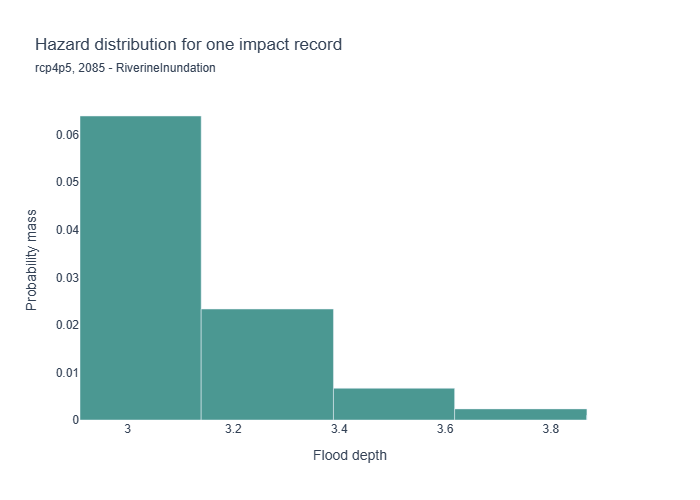

In [15]:
selected_index = 2
selected_impact = df_asset_impacts.iloc[selected_index]

hazard_distribution = selected_impact["calc_details"]["hazard_distribution"]
hazard_figure = distribution_to_figure(
    hazard_distribution,
    title=(
        "Hazard distribution for one impact record"
        f"<br><span style='font-size:12px'>{selected_impact['key']['scenario_id']}, "
        f"{selected_impact['key']['year']} - {selected_impact['key']['hazard_type']}</span>"
    ),
    xaxis_title="Flood depth",
    color="#0f766e",
)
hazard_figure

## 13. Visualize the Resulting Impact Distribution

`impact_distribution` represents the modeled impact for the selected asset after Alpha-Klima combines:

- hazard intensity,
- asset metadata,
- and the relevant vulnerability logic.

The impact unit depends on the model and endpoint configuration. In this example, it is a fractional damage-style impact distribution.

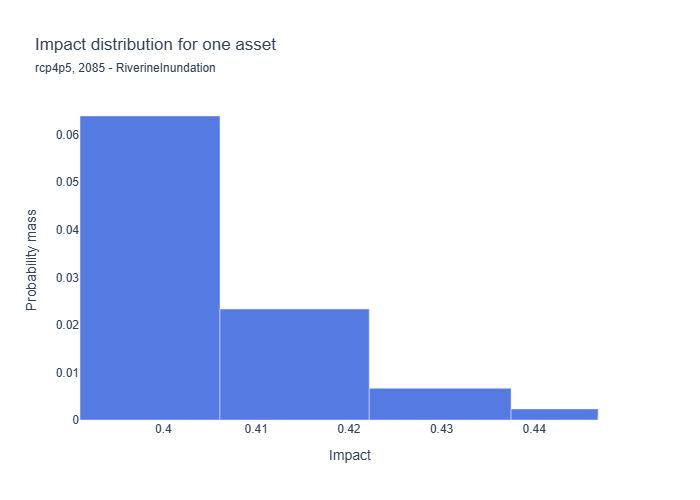

In [16]:
impact_distribution = selected_impact["impact_distribution"]
impact_figure = distribution_to_figure(
    impact_distribution,
    title=(
        "Impact distribution for one asset"
        f"<br><span style='font-size:12px'>{selected_impact['key']['scenario_id']}, "
        f"{selected_impact['key']['year']} - {selected_impact['key']['hazard_type']}</span>"
    ),
    xaxis_title="Impact",
    color="#1d4ed8",
)
impact_figure

## 14. Where This Fits in the Broader Workflow

Use the hazard-data notebook when you need direct access to hazard intensities at points. Use this notebook when you want Alpha-Klima to convert hazard information into asset-level impact distributions.

Portfolio, clustering, and banking notebooks build on the same idea, but aggregate those asset-level results into broader workflow outputs.